In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# ============================================================
# ГЛОБАЛЬНЫЕ КОНСТАНТЫ
# ============================================================
C_SI = 299792458.0

# ============================================================
# ОПТИЧЕСКИЕ МАТЕРИАЛЫ (Формулы Селмейера)
# ============================================================

class Material:
    def get_n(self, lambda_um, pol="o"): 
        raise NotImplementedError

class Air(Material):
    def get_n(self, lambda_um, pol="o"):
        lam2 = np.asarray(lambda_um) ** 2
        return 1 + 0.05792105 / (238.0185 - 1/lam2) + 0.00167917 / (57.362 - 1/lam2)

class BBO(Material):
    def get_n(self, lambda_um, pol="o"):
        lam2 = np.asarray(lambda_um) ** 2
        if pol == "o":
            n2 = 0.90291 * lam2 / (lam2 - 0.003926) + 0.83155 * lam2 / (lam2 - 0.018786) + 0.76536 * lam2 / (lam2 - 60.01) + 1
        elif pol == "e":
            n2 = 1.151075 * lam2 / (lam2 - 0.007142) + 0.21803 * lam2 / (lam2 - 0.02259) + 0.656 * lam2 / (lam2 - 263) + 1
        return np.sqrt(n2)
    
    def get_n_eff(self, lambda_um, psi_rad):
        n_o = self.get_n(lambda_um, "o")
        n_e = self.get_n(lambda_um, "e")
        return 1.0 / np.sqrt((np.cos(psi_rad)**2) / (n_o**2) + (np.sin(psi_rad)**2) / (n_e**2))

class GlassBK7(Material):
    def get_n(self, lambda_um, pol="o"):
        lam2 = np.asarray(lambda_um) ** 2
        B1, B2, B3 = 1.03961212, 0.231792344, 1.01046945
        C1, C2, C3 = 0.00600069867, 0.0200179144, 103.560653
        n2 = 1 + (B1 * lam2 / (lam2 - C1)) + (B2 * lam2 / (lam2 - C2)) + (B3 * lam2 / (lam2 - C3))
        return np.sqrt(n2)

# ============================================================
# СТРУКТУРА СЛОЯ
# ============================================================

class Layer:
    def __init__(self, material, thickness, pol_p="o", pol_s="o", pol_i="o", is_source=False, name="Слой"):
        self.material = material
        self.thickness = thickness
        self.pol_p = pol_p
        self.pol_s = pol_s
        self.pol_i = pol_i
        self.is_source = is_source
        self.name = name

# ============================================================
# КЛАСС ЭКСПЕРИМЕНТА (Основной управляющий элемент)
# ============================================================
class SPDCExperiment:
    def __init__(self, layers=None, lambda_pump_nm=404.0):
        self.layers = layers if layers is not None else []
        self.lambda_pump_nm = lambda_pump_nm
        self.w_pump = 2 * np.pi * C_SI / (lambda_pump_nm * 1e-9)
        self.psi_cut = self._find_bbo_cut_angle()

    def _find_bbo_cut_angle(self):
        """Внутренний метод для автоматического поиска угла синхронизма BBO."""
        bbo = BBO()
        lam_p_um = self.lambda_pump_nm * 1e-3
        lam_s_um = lam_p_um * 2
        n_s_deg = bbo.get_n(lam_s_um, "o")
        sol = root_scalar(lambda psi: bbo.get_n_eff(lam_p_um, psi) - n_s_deg, bracket=[0, np.pi/2])
        return sol.root

    def add_layer(self, layer):
        """Позволяет динамически добавлять слои в систему."""
        self.layers.append(layer)

    def clear_layers(self):
        """Очистить конфигурацию эксперимента."""
        self.layers = []

    def calculate_jsa(self, w_s, q_s):
        """Рассчитывает комплексную амплитуду бифотонов для текущих сеток частот и импульсов."""
        F_total = np.zeros_like(w_s, dtype=complex)
        accumulated_phase = np.zeros_like(w_s, dtype=complex)
        
        w_i = self.w_pump - w_s
        lam_p_um = (2 * np.pi * C_SI / self.w_pump) * 1e6
        lam_s_um = (2 * np.pi * C_SI / w_s) * 1e6
        lam_i_um = (2 * np.pi * C_SI / w_i) * 1e6

        for layer in self.layers:
            n_s = layer.material.get_n(lam_s_um, layer.pol_s)
            n_i = layer.material.get_n(lam_i_um, layer.pol_i)
            
            k_s = n_s * w_s / C_SI
            k_i = n_i * w_i / C_SI
            
            k_sz = np.sqrt(np.clip(k_s**2 - q_s**2, 0, None))
            k_iz = np.sqrt(np.clip(k_i**2 - q_s**2, 0, None))
            
            if layer.is_source:
                if isinstance(layer.material, BBO) and layer.pol_p == "eff":
                    n_p = layer.material.get_n_eff(lam_p_um, self.psi_cut)
                else:
                    n_p = layer.material.get_n(lam_p_um, layer.pol_p)
                k_p = n_p * self.w_pump / C_SI
                
                dk = k_p - k_sz - k_iz
                sinc_part = np.sinc(dk * layer.thickness / (2 * np.pi))
                layer_amplitude = layer.thickness * sinc_part * np.exp(1j * dk * layer.thickness / 2)
                
                F_total += layer_amplitude * np.exp(1j * accumulated_phase)
                accumulated_phase += dk * layer.thickness
            else:
                n_p_layer = layer.material.get_n(lam_p_um, layer.pol_p)
                k_p_layer = n_p_layer * self.w_pump / C_SI
                
                dk_layer = k_p_layer - k_sz - k_iz
                accumulated_phase += dk_layer * layer.thickness
                
        return F_total

    def run_angular_phase_benchmark(self, theta_deg_list=[0.0, 0.2, 0.5, 1.0, 1.5, 2.0]):
        """Бенчмарк: выводит относительный набег фазы d𝜙(𝜃) для каждого линейного слоя."""
        print("\n" + "="*80)
        print(" ООП БЕНЧМАРК: Набег относительной фазы d𝜙(𝜃) в линейных слоях схемы")
        print(" (Зафиксирован вырожденный режим 808 нм. Относительно центра оси 𝜃 = 0°)")
        print("="*80)
        
        air_ref = Air()
        w_s_deg = self.w_pump / 2
        lam_p_um, lam_s_um = self.lambda_pump_nm * 1e-3, (self.lambda_pump_nm * 2) * 1e-3
        
        k_air_s = air_ref.get_n(lam_s_um) * w_s_deg / C_SI

        for layer in self.layers:
            if layer.is_source:
                continue
                
            print(f"\n>> Анализ слоя: {layer.name} (Толщина: {layer.thickness*1e3:.2f} мм)")
            print("-" * 65)
            
            n_p_0 = layer.material.get_n(lam_p_um, layer.pol_p)
            n_s_0 = layer.material.get_n(lam_s_um, layer.pol_s)
            k_p_0 = n_p_0 * self.w_pump / C_SI
            k_s_0 = n_s_0 * w_s_deg / C_SI
            
            dk_0 = k_p_0 - 2 * k_s_0
            phase_0 = dk_0 * layer.thickness
            
            for theta_deg in theta_deg_list:
                q_s = k_air_s * np.sin(np.radians(theta_deg))
                
                n_p = layer.material.get_n(lam_p_um, layer.pol_p)
                n_s = layer.material.get_n(lam_s_um, layer.pol_s)
                
                k_p = n_p * self.w_pump / C_SI
                k_s = n_s * w_s_deg / C_SI
                
                k_sz = np.sqrt(np.clip(k_s**2 - q_s**2, 0, None))
                dk_theta = k_p - 2 * k_sz
                phase_theta = dk_theta * layer.thickness
                
                delta_phase = phase_theta - phase_0
                turns = delta_phase / (2 * np.pi)
                
                print(f"  Угол 𝜃 = {theta_deg:3.1f}° | Относит. фаза = {delta_phase:7.2f} рад | Проворотов (𝜙/2𝜋) = {turns:6.2f}")
        print("="*80 + "\n")

    # ============================================================
    # ОБНОВЛЕННЫЙ МЕТОД ПОСТРОЕНИЯ КАРТИНКИ
    # ============================================================
    def plot_experiment_image(self, lambda_range_nm=(700, 900), theta_range_deg=(-2.0, 2.0), 
                              lambda_count=500, theta_count=500):
        """
        Строит и выводит 2D-картину распределения интенсивности СПР.
        
        Параметры:
        ----------
        lambda_range_nm : tuple
            Минимальная и максимальная длина волны спектрометра (в нм).
        theta_range_deg : tuple
            Минимальный и максимальный внешний угол вылета (в градусах).
        lambda_count : int
            Разрешение по оси длин волн (количество точек).
        theta_count : int
            Разрешение по оси углов (количество точек).
        """
        # Прямая генерация сетки углов в радианах из заданного диапазона в градусах
        theta_array = np.radians(np.linspace(theta_range_deg[0], theta_range_deg[1], theta_count))
        lambdas_nm = np.linspace(lambda_range_nm[0], lambda_range_nm[1], lambda_count)

        w_signal_array = 2 * np.pi * C_SI / (lambdas_nm * 1e-9)
        w_s_mesh, theta_s_mesh = np.meshgrid(w_signal_array, theta_array)

        # q_s через воздух снаружи
        air_ref = Air()
        n_air_mesh = air_ref.get_n((2 * np.pi * C_SI / w_s_mesh) * 1e6)
        k_air_mesh = n_air_mesh * w_s_mesh / C_SI
        q_s_mesh = k_air_mesh * np.sin(theta_s_mesh)

        # Расчет
        F = self.calculate_jsa(w_s_mesh, q_s_mesh)
        Intensity = np.abs(F) ** 2
        
        # Защита от деления на ноль, если интенсивность всюду нулевая
        max_int = np.max(Intensity)
        if max_int > 0:
            Intensity /= max_int

        # Отрисовка
        plt.figure(figsize=(11, 6.5))
        plt.imshow(
            Intensity, 
            extent=[lambdas_nm.min(), lambdas_nm.max(), theta_range_deg[0], theta_range_deg[1]],
            aspect='auto', origin='lower', cmap='jet'
        )
        plt.colorbar(label='Нормированная интенсивность света')
        plt.title('ООП Модель: Распределение интенсивности СПР на матрице спектрометра')
        plt.xlabel('Длина волны $\lambda_s$, нм (Развертка призмы)')
        plt.ylabel('Внешний угол вылета $\theta$, град')
        plt.grid(True, alpha=0.25, linestyle='--')
        plt.show()



<>:225: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:225: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\RedBrean\AppData\Local\Temp\ipykernel_1696\1202459606.py:225: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.xlabel('Длина волны $\lambda_s$, нм (Развертка призмы)')



 ООП БЕНЧМАРК: Набег относительной фазы d𝜙(𝜃) в линейных слоях схемы
 (Зафиксирован вырожденный режим 808 нм. Относительно центра оси 𝜃 = 0°)

>> Анализ слоя: Воздушный зазор 1 (Толщина: 54.00 мм)
-----------------------------------------------------------------
  Угол 𝜃 = 0.0° | Относит. фаза =    0.00 рад | Проворотов (𝜙/2𝜋) =   0.00
  Угол 𝜃 = 0.2° | Относит. фаза =    5.12 рад | Проворотов (𝜙/2𝜋) =   0.81
  Угол 𝜃 = 0.5° | Относит. фаза =   31.99 рад | Проворотов (𝜙/2𝜋) =   5.09
  Угол 𝜃 = 1.0° | Относит. фаза =  127.95 рад | Проворотов (𝜙/2𝜋) =  20.36
  Угол 𝜃 = 1.5° | Относит. фаза =  287.87 рад | Проворотов (𝜙/2𝜋) =  45.82
  Угол 𝜃 = 2.0° | Относит. фаза =  511.74 рад | Проворотов (𝜙/2𝜋) =  81.45

>> Анализ слоя: Оптическое стекло BK7 (Толщина: 3.07 мм)
-----------------------------------------------------------------
  Угол 𝜃 = 0.0° | Относит. фаза =    0.00 рад | Проворотов (𝜙/2𝜋) =   0.00
  Угол 𝜃 = 0.2° | Относит. фаза =    0.19 рад | Проворотов (𝜙/2𝜋) =   0.03
  Угол 𝜃 = 0

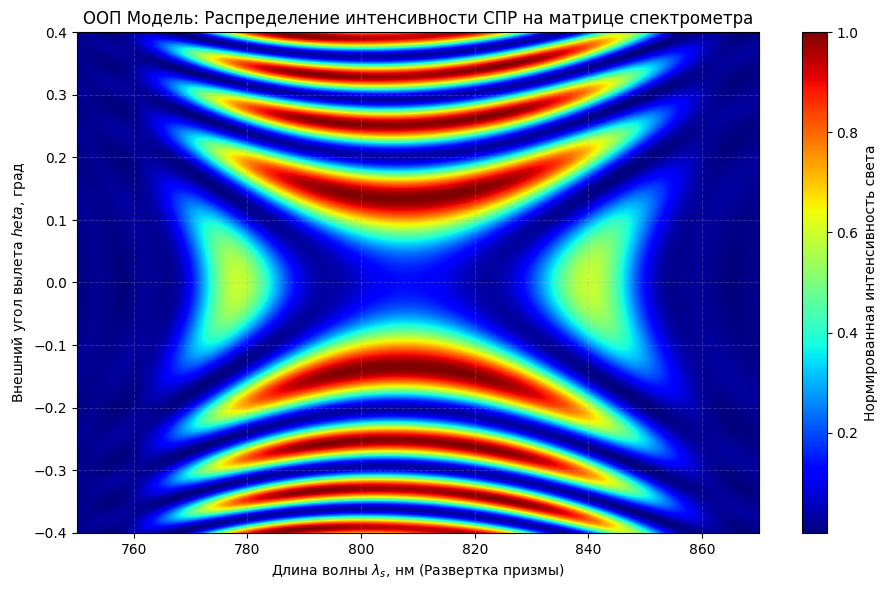

In [27]:
# Инициализируем материалы
air = Air()
bbo = BBO()
glass = GlassBK7()

# Создаем объект эксперимента (накачка 404 нм задана внутри по умолчанию)
experiment = SPDCExperiment()

# Набираем слои («пирог» нашего стенда)
experiment.add_layer(Layer(bbo, thickness=3.0e-3, pol_p="eff", is_source=True, name="Кристалл 1 (BBO)"))
experiment.add_layer(Layer(air, thickness=54e-3, is_source=False, name="Воздушный зазор 1"))
experiment.add_layer(Layer(glass, thickness=3e-3 / np.cos(np.radians(12)), is_source=False, name="Оптическое стекло BK7"))
experiment.add_layer(Layer(air, thickness=0e-3, is_source=False, name="Воздушный зазор 2"))
experiment.add_layer(Layer(bbo, thickness=4.3e-3, pol_p="eff", is_source=True, name="Кристалл 2 (BBO)"))

# 1. Запускаем бенчмарк угловой фазы для промежуточных сред
experiment.run_angular_phase_benchmark()

# 2. Строим 2D картинку интерференции, которая полетит на камеру спектрометра
experiment.plot_experiment_image(theta_range_deg=(-0.4, 0.4), lambda_range_nm=(750, 870))

<>:224: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:224: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\RedBrean\AppData\Local\Temp\ipykernel_21284\494330312.py:224: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.xlabel('Длина волны сигнала $\lambda_s$, нм')


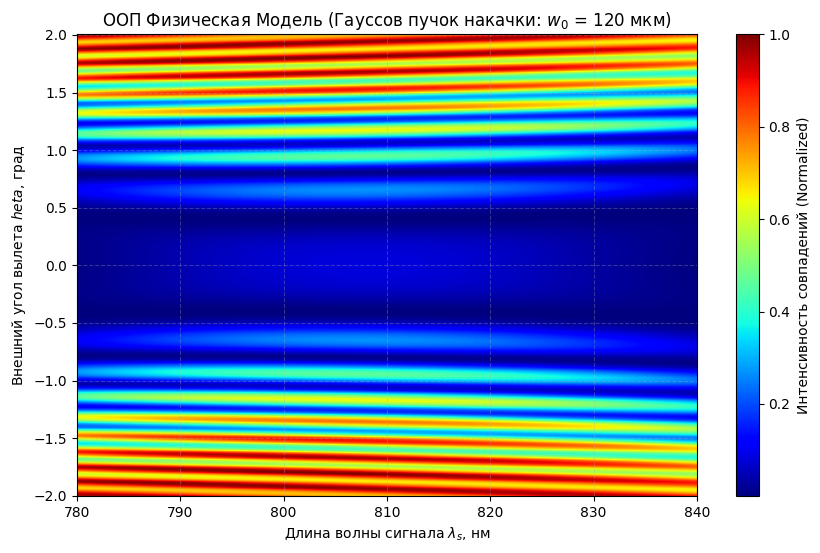

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

C_SI = 299792458.0

# ============================================================
# ДИСПЕРСИОННЫЕ МАТЕРИАЛЫ
# ============================================================

class Material:
    """Абстрактный класс оптической среды."""
    def get_refractive_index(self, lambda_um: float, polarization: str = "o") -> float:
        raise NotImplementedError

class Air(Material):
    def get_refractive_index(self, lambda_um: float, polarization: str = "o") -> float:
        lam2 = np.asarray(lambda_um) ** 2
        return 1 + 0.05792105 / (238.0185 - 1 / lam2) + 0.00167917 / (57.362 - 1 / lam2)

class GlassBK7(Material):
    def get_refractive_index(self, lambda_um: float, polarization: str = "o") -> float:
        lam2 = np.asarray(lambda_um) ** 2
        B1, B2, B3 = 1.03961212, 0.231792344, 1.01046945
        C1, C2, C3 = 0.00600069867, 0.0200179144, 103.560653
        n2 = 1 + (B1 * lam2 / (lam2 - C1)) + (B2 * lam2 / (lam2 - C2)) + (B3 * lam2 / (lam2 - C3))
        return np.sqrt(n2)

class BBO(Material):
    def get_refractive_index(self, lambda_um: float, polarization: str = "o") -> float:
        lam2 = np.asarray(lambda_um) ** 2
        if polarization == "o":
            n2 = 0.90291 * lam2 / (lam2 - 0.003926) + 0.83155 * lam2 / (lam2 - 0.018786) + 0.76536 * lam2 / (lam2 - 60.01) + 1
        elif polarization == "e":
            n2 = 1.151075 * lam2 / (lam2 - 0.007142) + 0.21803 * lam2 / (lam2 - 0.02259) + 0.656 * lam2 / (lam2 - 263) + 1
        else:
            raise ValueError(f"Unknown polarization: {polarization}")
        return np.sqrt(n2)
    
    def get_effective_index(self, lambda_um: float, theta_cut_rad: float) -> float:
        n_o = self.get_refractive_index(lambda_um, "o")
        n_e = self.get_refractive_index(lambda_um, "e")
        return 1.0 / np.sqrt((np.cos(theta_cut_rad)**2) / (n_o**2) + (np.sin(theta_cut_rad)**2) / (n_e**2))


# ============================================================
# ФИЗИЧЕСКИЕ СУЩНОСТИ И ПРОФИЛИ ПУЧКОВ
# ============================================================

class PhotonMode:
    """Хранит и пересчитывает волновые параметры фотона в конкретной среде."""
    def __init__(self, omega: np.ndarray, q_transverse: np.ndarray):
        self.omega = omega              # Циклическая частота (рад/с)
        self.q = q_transverse           # Поперечный импульс q_s (рад/м)
        self.lambda_um = (2 * np.pi * C_SI / omega) * 1e6
        
    def get_k_vectors(self, material: Material, polarization: str, theta_cut: float = 0.0):
        """Возвращает полный волновой вектор k и его продольную проекцию k_z."""
        if isinstance(material, BBO) and polarization == "eff":
            n = material.get_effective_index(self.lambda_um, theta_cut)
        else:
            n = material.get_refractive_index(self.lambda_um, polarization)
            
        k_full = n * self.omega / C_SI
        k_z = np.sqrt(np.clip(k_full**2 - self.q**2, 0, None))
        return k_full, k_z


class GaussianPumpBeam:
    """Отвечает за пространственный профиль лазера накачки."""
    def __init__(self, lambda_nm: float, waist_radius_um: float):
        self.lambda_nm = lambda_nm
        self.omega = 2 * np.pi * C_SI / (lambda_nm * 1e-9)
        self.w0 = waist_radius_um * 1e-6
        
    def get_spatial_overlap(self, walkoff_m: np.ndarray) -> np.ndarray:
        """Вычисляет гауссово подавление интерференции при сносе лучей из пучка."""
        return np.exp(- (walkoff_m**2) / (self.w0**2))


# ============================================================
# ИЕРАРХИЯ ОПТИЧЕСКИХ СЛОЕВ
# ============================================================

class BaseLayer:
    """Абстрактный оптический слой."""
    def __init__(self, material: Material, thickness_m: float, pol_p: str, pol_s: str, pol_i: str, name: str):
        self.material = material
        self.thickness = thickness_m
        self.pol_p = pol_p
        self.pol_s = pol_s
        self.pol_i = pol_i
        self.name = name

    def EvolveState(self, signal: PhotonMode, idler: PhotonMode, pump: GaussianPumpBeam, 
                    current_phase: np.ndarray, current_walkoff: np.ndarray, psi_cut: float):
        """Продвигает фазу и пространственный снос пучка сквозь слой."""
        _, k_sz = signal.get_k_vectors(self.material, self.pol_s)
        _, k_iz = idler.get_k_vectors(self.material, self.pol_i)
        
        n_p = self.material.get_refractive_index(pump.lambda_nm * 1e-3, self.pol_p)
        k_p = n_p * pump.omega / C_SI
        
        dk = k_p - k_sz - k_iz
        
        # Обновление фазы
        next_phase = current_phase + dk * self.thickness
        
        # Обновление пространственного смещения луча (walk-off) по законам Снеллиуса/Фун Фурье-оптики
        tan_theta = np.zeros_like(signal.q)
        mask = k_sz > 0
        tan_theta[mask] = signal.q[mask] / k_sz[mask]
        next_walkoff = current_walkoff + self.thickness * tan_theta
        
        return next_phase, next_walkoff, dk


class PassiveLayer(BaseLayer):
    """Пассивный слой (воздух, стеклянная подложка, компенсатор фазы)."""
    def compute_contribution(self, signal, idler, pump, current_phase, current_walkoff, psi_cut):
        # Пассивный слой не генерирует новые пары фотонов, только меняет фазу и сносит геометрию
        next_phase, next_walkoff, _ = self.EvolveState(signal, idler, pump, current_phase, current_walkoff, psi_cut)
        return 0.0, next_phase, next_walkoff


class ActiveLayer(BaseLayer):
    """Активный нелинейный слой (кристалл-генератор СПР)."""
    def compute_contribution(self, signal, idler, pump, current_phase, current_walkoff, psi_cut):
        # Считаем эволюцию волновых векторов в кристалле
        _, k_sz = signal.get_k_vectors(self.material, self.pol_s)
        _, k_iz = idler.get_k_vectors(self.material, self.pol_i)
        
        n_p = self.material.get_effective_index(pump.lambda_nm * 1e-3, psi_cut) if isinstance(self.material, BBO) and self.pol_p == "eff" else self.material.get_refractive_index(pump.lambda_nm * 1e-3, self.pol_p)
        k_p = n_p * pump.omega / C_SI
        
        dk = k_p - k_sz - k_iz
        
        # Локальная амплитуда генерации в кристалле (классический sinc)
        sinc_part = np.sinc(dk * self.thickness / (2 * np.pi))
        layer_amplitude = self.thickness * sinc_part * np.exp(1j * dk * self.thickness / 2)
        
        # Применяем пространственное затухание (насколько хорошо перекрываются моды)
        spatial_overlap = pump.get_spatial_overlap(current_walkoff)
        
        # Итоговый когерентный вклад слоя в общую интерференционную функцию
        amplitude_contribution = layer_amplitude * np.exp(1j * current_phase) * spatial_overlap
        
        # Пересчитываем глобальные фазы и геометрию для следующих по ходу луча слоев
        next_phase, next_walkoff, _ = self.EvolveState(signal, idler, pump, current_phase, current_walkoff, psi_cut)
        
        return amplitude_contribution, next_phase, next_walkoff


# ============================================================
# СИСТЕМА УПРАВЛЕНИЯ ОПТИЧЕСКИМ СТЕНДОМ
# ============================================================

class SPDCSystem:
    """Управляющий класс оптической системы (аналог лабораторной схемы)."""
    def __init__(self, pump_beam: GaussianPumpBeam):
        self.pump = pump_beam
        self.layers = []
        self.psi_cut = self._calculate_bbo_matching_angle()

    def _calculate_bbo_matching_angle(self) -> float:
        bbo = BBO()
        lam_p_um = self.pump.lambda_nm * 1e-3
        lam_s_um = lam_p_um * 2
        n_s_deg = bbo.get_refractive_index(lam_s_um, "o")
        sol = root_scalar(lambda psi: bbo.get_effective_index(lam_p_um, psi) - n_s_deg, bracket=[0, np.pi/2])
        return sol.root

    def append_layer(self, layer: BaseLayer):
        self.layers.append(layer)

    def calculate_jsa(self, w_s: np.ndarray, q_s: np.ndarray) -> np.ndarray:
        """Считает результирующую функцию JSA, опрашивая слои по цепочке Responsibilities."""
        signal_mode = PhotonMode(omega=w_s, q_transverse=q_s)
        idler_mode = PhotonMode(omega=self.pump.omega - w_s, q_transverse=q_s)
        
        total_amplitude = np.zeros_like(w_s, dtype=complex)
        current_phase = np.zeros_like(w_s, dtype=complex)
        current_walkoff = np.zeros_like(w_s, dtype=float)
        
        for layer in self.layers:
            amp_contrib, current_phase, current_walkoff = layer.compute_contribution(
                signal_mode, idler_mode, self.pump, current_phase, current_walkoff, self.psi_cut
            )
            total_amplitude += amp_contrib
            
        return total_amplitude

    def plot_spectrum_map(self, lambda_min_nm=780, lambda_max_nm=840, pixel_count=400):
        """Визуализация спектрально-угловой интерференционной картины."""
        pixels_x = np.linspace(0, 500, pixel_count)
        lambdas_nm = np.linspace(lambda_min_nm, lambda_max_nm, pixel_count)

        # Пересчет пикселей матрицы в физические углы вылета снаружи кристалла
        theta_array = -0.035 + 0.00014 * pixels_x
        w_signal_array = 2 * np.pi * C_SI / (lambdas_nm * 1e-9)
        
        w_s_mesh, theta_s_mesh = np.meshgrid(w_signal_array, theta_array)

        # Вычисляем сетку поперечных импульсов q_s, зная углы в воздухе перед детектором
        air = Air()
        n_air_mesh = air.get_refractive_index((2 * np.pi * C_SI / w_s_mesh) * 1e6)
        q_s_mesh = (n_air_mesh * w_s_mesh / C_SI) * np.sin(theta_s_mesh)

        # Рассчитываем интерференционную картину
        jsa = self.calculate_jsa(w_s_mesh, q_s_mesh)
        intensity = np.abs(jsa) ** 2
        
        if np.max(intensity) > 0:
            intensity /= np.max(intensity)

        plt.figure(figsize=(10, 6))
        plt.imshow(
            intensity, 
            extent=[lambdas_nm.min(), lambdas_nm.max(), np.degrees(theta_array.min()), np.degrees(theta_array.max())],
            aspect='auto', origin='lower', cmap='jet'
        )
        plt.colorbar(label='Интенсивность совпадений (Normalized)')
        plt.title(f'ООП Физическая Модель (Гауссов пучок накачки: $w_0$ = {self.pump.w0*1e6:.0f} мкм)')
        plt.xlabel('Длина волны сигнала $\lambda_s$, нм')
        plt.ylabel('Внешний угол вылета $\theta$, град')
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.show()


# ============================================================
# ТОЧКА ВХОДА В СИМУЛЯЦИЮ
# ============================================================
if __name__ == "__main__":
    # 1. Создаем физическую накачку
    laser = GaussianPumpBeam(lambda_nm=404.0, waist_radius_um=120.0)
    
    # 2. Инициализируем оптическую систему
    system = SPDCSystem(pump_beam=laser)
    
    # 3. Конфигурируем геометрию (Сэндвич-интерферометр)
    system.append_layer(ActiveLayer(material=BBO(), thickness_m=0.5e-3, pol_p="e", pol_s="o", pol_i="o", name="BBO Кристалл 1"))
    system.append_layer(PassiveLayer(material=Air(), thickness_m=5.2e-3, pol_p="o", pol_s="o", pol_i="o", name="Воздушный зазор"))
    system.append_layer(ActiveLayer(material=BBO(), thickness_m=0.5e-3, pol_p="e", pol_s="o", pol_i="o", name="BBO Кристалл 2"))

    # 4. Запускаем симуляцию эксперимента
    system.plot_spectrum_map()